In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

def func(x, m = 2, A=1, B=0):            
    buf = np.where((abs(x)<np.pi/2), 1, 0)        
    buff = np.where(np.cos(x)>0,(A*np.power(np.cos(x),m)+B),0) 

    return buf*buff

def errorRound(val, ndigits):
    return round(1 + val*10**ndigits)/(10**ndigits)

xrange = np.linspace(0, np.pi/2, 1000)

deltaTheta = 66.2 * (np.pi/180)

nRange = np.linspace(1.8, 2.5, 20)

C:\Users\Dumitru Andrei\AppData\Local\Temp\ipykernel_26528\3931321977.py:7: RuntimeWarning: invalid value encountered in power
  buff = np.where(np.cos(x)>0,(A*np.power(np.cos(x),m)+B),0)


[ 2.07617345 -1.80246671]
[[ 0.0001303  -0.00024805]
 [-0.00024805  0.00047358]]
a=2.08 $\pm$ 0.02
b=-1.8 $\pm$ 0.03


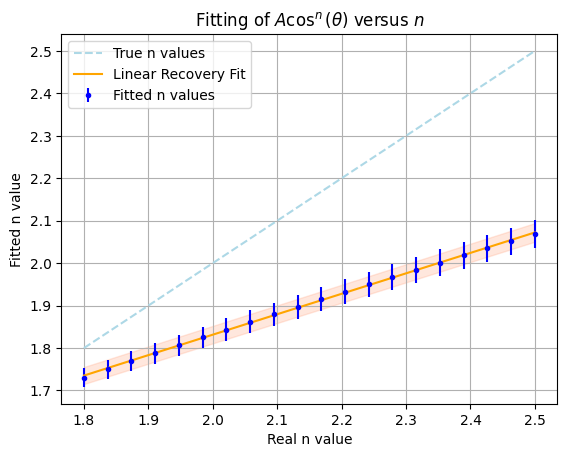

In [9]:
#plt.plot(xrange, func(xrange), color='blue')

samples = 20
nList = []
nErrs = []
sampling = np.linspace(0, (np.pi/2)*0.999, samples)

for nval in nRange:
    res = np.array([scipy.integrate.quad(lambda x: func(x,m=nval), sample-deltaTheta/2, sample+deltaTheta/2)[0] for sample in sampling])

    popt, pcov = scipy.optimize.curve_fit(func, xdata=sampling, ydata=res)

    nList.append(popt[0])
    nErrs.append(np.sqrt(pcov[0][0]))

#angle = nRange[np.argmin(abs(thetaRange-66.2* (np.pi/180)))]
#n = nList[np.argmin(abs(thetaRange-66.2* (np.pi/180)))]
#nerr = nErrs[np.argmin(abs(thetaRange-66.2* (np.pi/180)))]

popt, pcov = scipy.optimize.curve_fit(lambda x,a,b: a*x+b, xdata=nList, ydata=nRange)
print(popt)
print(pcov)

plt.errorbar(nRange, nList, yerr = nErrs, fmt = '.', color = 'blue', label = "Fitted n values")
plt.plot(nRange, nRange, color = 'lightblue', alpha=1.0, linestyle = 'dashed', label = "True n values")
plt.plot(nRange, (1/popt[0])* (nRange-popt[1]), color = 'orange', label = 'Linear Recovery Fit')

oldx, oldy = plt.xlim(), plt.ylim()

p0rnge = np.linspace(popt[0]-np.sqrt(pcov[0][0]), popt[0]+np.sqrt(pcov[0][0]), 20)
p1rnge = np.linspace(popt[1]-np.sqrt(pcov[1][1]), popt[1]+np.sqrt(pcov[1][1]), 20)

ymin2 = (1/p0rnge[0])*(nRange - p1rnge[0]) 
ymax2 = (1/p0rnge[0])*(nRange - p1rnge[0]) 

for p0 in p0rnge:
    for p1 in p1rnge:
            buf = (1/p0)*(nRange - p1) 
            ymin2 = np.minimum(ymin2, buf)
            ymax2 = np.maximum(ymax2, buf)

plt.fill_between(nRange,ymin2,ymax2,color = 'lightsalmon', alpha = 0.25)

#plt.vlines(x=66.2, ymin = oldy[0]*(-1), ymax = oldy[1]*1.1, color='orange', alpha = 0.6, linestyle ='dashed', label = "66.2 Deg")
#plt.hlines(y=2   , xmin = oldx[0]*(-1), xmax = oldx[1]*1.1, color='lightblue',  alpha = 1.0, linestyle ='dashed')
#plt.hlines(y=n   , xmin = oldx[0]*(-1), xmax = oldx[1]*1.1, color='lightblue',  alpha = 1.0, linestyle ='dashed', label = rf"n={round(n,2)} $\pm$ {errorRound(nerr,2)}")

print(rf"a={round(popt[0],2)} $\pm$ {errorRound(np.sqrt(pcov[0][0]),2)}")
print(rf"b={round(popt[1],2)} $\pm$ {errorRound(np.sqrt(pcov[1][1]),2)}")


plt.xlim(oldx)
plt.ylim(oldy)

plt.title(r'Fitting of $A\cos^n(\theta)$ versus $n$')
plt.xlabel('Real n value')
plt.ylabel('Fitted n value')

plt.grid()
plt.legend()

plt.show()
